# Phase 2 — Prédiction 3D
## Unscented Kalman Filter 3D + LSTM 3D + Modèle Hybride UKF+LSTM
### Simulateur Iron Dome — PFA ENSTAB

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sys
sys.path.append('../src')
from simulation.rocket3d import Rocket3D, ThreatGenerator3D
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## 1. Radar 3D — Simulation des mesures bruitées

In [2]:
class Radar3D:
    """Simule un radar 3D avec bruit de mesure."""
    def __init__(self, sigma=30, frequence=10):
        self.sigma = sigma
        self.frequence = frequence
    
    def observer(self, t_vrai, x_vrai, y_vrai, z_vrai, duree=8.0):
        masque = t_vrai <= duree
        t_ob = t_vrai[masque]; x_ob = x_vrai[masque]
        y_ob = y_vrai[masque]; z_ob = z_vrai[masque]
        ind = np.arange(0, len(t_ob), max(1, int(1.0/(self.frequence*0.1))))
        t = t_ob[ind]; xr = x_ob[ind]; yr = y_ob[ind]; zr = z_ob[ind]
        xb = xr + np.random.normal(0, self.sigma, len(t))
        yb = np.maximum(yr + np.random.normal(0, self.sigma, len(t)), 0)
        zb = zr + np.random.normal(0, self.sigma, len(t))
        return {'t':t, 'x':xb, 'y':yb, 'z':zb,
                'x_vrai':xr, 'y_vrai':yr, 'z_vrai':zr, 'n':len(t)}

# Test
np.random.seed(42)
roquette = Rocket3D(v0=300, theta_deg=50, phi_deg=10, masse=100,
                     Cd=0.3, A=0.05, x0=-5000, y0=0, z0=500)
t_vrai, x_vrai, y_vrai, z_vrai = roquette.trajectoire_rk4(dt=0.1)

radar = Radar3D(sigma=30, frequence=10)
mesures = radar.observer(t_vrai, x_vrai, y_vrai, z_vrai, duree=8.0)
print(f"Mesures radar 3D : {mesures['n']} points sur {mesures['t'][-1]:.1f}s")
print(f"Vol total : {t_vrai[-1]:.1f}s")

Mesures radar 3D : 81 points sur 8.0s
Vol total : 40.5s


## 2. Unscented Kalman Filter 3D
État : [x, y, z, vx, vy, vz, k] — 7 dimensions

Le coefficient de drag k est estimé conjointement avec la position et la vitesse.\n",
     "L\'UKF utilise la propagation par points sigma, éliminant le besoin de Jacobiennes analytiques.

In [3]:
import scipy.linalg as linalg

class UKF3D:
    """
    Unscented Kalman Filter en 3D.
    Etat : [x, y, z, vx, vy, vz, k] (7 dimensions)
    k = coefficient de drag estime conjointement.
    Utilise la propagation par points sigma (Merwe Scaled),
    eliminant le besoin de Jacobiennes analytiques.
    """
    def __init__(self, sigma_mesure=30.0):
        self.g = 9.81
        self.sm = sigma_mesure
        self.n = 7
        self.alpha = 1e-3
        self.beta = 2
        self.kappa = 0
        self.lam = self.alpha**2 * (self.n + self.kappa) - self.n
        self.Wm = np.zeros(2 * self.n + 1)
        self.Wc = np.zeros(2 * self.n + 1)
        self.Wm[0] = self.lam / (self.n + self.lam)
        self.Wc[0] = self.lam / (self.n + self.lam) + (1 - self.alpha**2 + self.beta)
        for i in range(1, 2 * self.n + 1):
            self.Wm[i] = 1.0 / (2 * (self.n + self.lam))
            self.Wc[i] = 1.0 / (2 * (self.n + self.lam))
        self.H = np.zeros((3, 7))
        self.H[0,0] = 1; self.H[1,1] = 1; self.H[2,2] = 1
        self.R = np.eye(3) * sigma_mesure**2

    def _generer_points_sigma(self, x, P):
        try:
            U = linalg.cholesky((self.n + self.lam) * P)
        except linalg.LinAlgError:
            U = linalg.cholesky((self.n + self.lam) * (P + np.eye(self.n) * 1e-8))
        sigmas = np.zeros((2 * self.n + 1, self.n))
        sigmas[0] = x
        for k in range(self.n):
            sigmas[k + 1] = x + U[k]
            sigmas[self.n + k + 1] = x - U[k]
        return sigmas

    def _f(self, s, dt):
        """Transition non-lineaire (gravite + drag 3D)."""
        x, y, z, vx, vy, vz, k = s
        v = np.sqrt(vx**2 + vy**2 + vz**2)
        if v > 0 and k > 0:
            ax = -k*v*vx; ay = -self.g - k*v*vy; az = -k*v*vz
        else:
            ax = 0; ay = -self.g; az = 0
        return np.array([x+vx*dt+.5*ax*dt**2, y+vy*dt+.5*ay*dt**2,
                         z+vz*dt+.5*az*dt**2, vx+ax*dt, vy+ay*dt, vz+az*dt, k])

    def filtrer(self, t_obs, x_obs, y_obs, z_obs):
        """Filtrage UKF 3D : estime [x,y,z,vx,vy,vz,k]."""
        if len(t_obs) < 2:
            return np.array([[x_obs[0], y_obs[0], z_obs[0], 0, 0, 0, 0.0001]])
        dt = t_obs[1] - t_obs[0]
        K_SCALE = 10000.0
        n_init = min(5, len(t_obs))
        vx0 = np.polyfit(t_obs[:n_init], x_obs[:n_init], 1)[0]
        vy0 = np.polyfit(t_obs[:n_init], y_obs[:n_init], 1)[0]
        vz0 = np.polyfit(t_obs[:n_init], z_obs[:n_init], 1)[0]
        X = np.array([x_obs[0], y_obs[0], z_obs[0], vx0, vy0, vz0, 0.00008 * K_SCALE])
        P = np.diag([self.sm**2]*3 + [self.sm**2]*3 + [0.3**2])
        sigma_a = 2.0
        Q = np.diag([(0.5*sigma_a*dt**2)**2]*3 + [(sigma_a*dt)**2]*3 + [0.001**2])
        etats = []
        for j in range(len(t_obs)):
            # --- PREDICTION UKF ---
            sigmas = self._generer_points_sigma(X, P)
            sigmas_f = np.zeros_like(sigmas)
            for i in range(2 * self.n + 1):
                state = sigmas[i].copy()
                state[6] /= K_SCALE
                state_pred = self._f(state, dt)
                state_pred[6] *= K_SCALE
                sigmas_f[i] = state_pred
            X_pred = np.dot(self.Wm, sigmas_f)
            P_pred = Q.copy()
            for i in range(2 * self.n + 1):
                d = sigmas_f[i] - X_pred
                P_pred += self.Wc[i] * np.outer(d, d)
            # --- MISE A JOUR UKF ---
            sigmas_h = np.zeros((2 * self.n + 1, 3))
            for i in range(2 * self.n + 1):
                sigmas_h[i] = [sigmas_f[i, 0], sigmas_f[i, 1], sigmas_f[i, 2]]
            zp = np.dot(self.Wm, sigmas_h)
            S = self.R.copy()
            for i in range(2 * self.n + 1):
                dz = sigmas_h[i] - zp
                S += self.Wc[i] * np.outer(dz, dz)
            Pxz = np.zeros((self.n, 3))
            for i in range(2 * self.n + 1):
                Pxz += self.Wc[i] * np.outer(sigmas_f[i] - X_pred, sigmas_h[i] - zp)
            K_gain = np.dot(Pxz, linalg.inv(S))
            z_obs_vec = np.array([x_obs[j], y_obs[j], z_obs[j]])
            X = X_pred + np.dot(K_gain, z_obs_vec - zp)
            P = P_pred - np.dot(K_gain, np.dot(S, K_gain.T))
            X[6] = np.clip(X[6], 0.1, 8.0)
            etat = X.copy()
            etat[6] = etat[6] / K_SCALE
            etats.append(etat)
        return np.array(etats)

    def simuler_impact(self, etat, k_override=None, dt=0.1):
        """Simule jusqu'a l'impact, retourne (x_impact, z_impact)."""
        x,y,z,vx,vy,vz = etat[:6]
        k = k_override if k_override is not None else (etat[6] if len(etat)>6 else 0)
        preds = [np.array([x,y,z,vx,vy,vz])]
        for _ in range(5000):
            v = np.sqrt(vx**2+vy**2+vz**2)
            ax=-k*v*vx if v>0 and k>0 else 0
            ay=-self.g-k*v*vy if v>0 and k>0 else -self.g
            az=-k*v*vz if v>0 and k>0 else 0
            nx=x+vx*dt+.5*ax*dt**2;ny=y+vy*dt+.5*ay*dt**2;nz=z+vz*dt+.5*az*dt**2
            nvx=vx+ax*dt;nvy=vy+ay*dt;nvz=vz+az*dt
            if ny<0 and y>=0:
                f=y/(y-ny)
                preds.append(np.array([x+f*(nx-x),0,z+f*(nz-z),0,0,0]))
                break
            x,y,z,vx,vy,vz=nx,ny,nz,nvx,nvy,nvz
            preds.append(np.array([x,y,z,vx,vy,vz]))
        return np.array(preds)

    def pipeline_complet(self, t_obs, x_obs, y_obs, z_obs):
        """Pipeline UKF 3D complet."""
        etats = self.filtrer(t_obs, x_obs, y_obs, z_obs)
        preds = self.simuler_impact(etats[-1])
        preds_brut = self.simuler_impact(etats[-1], k_override=0)
        return {
            'etats_filtres': etats[:,:6],
            'predictions': preds, 'predictions_brutes': preds_brut,
            'x_impact': preds[-1][0], 'z_impact': preds[-1][2],
            'x_impact_brut': preds_brut[-1][0], 'z_impact_brut': preds_brut[-1][2],
            'k_estime': etats[-1][6]}


In [4]:
# Test UKF 3D
ukf = UKF3D(sigma_mesure=30)
res = ukf.pipeline_complet(mesures['t'], mesures['x'], mesures['y'], mesures['z'])

k_reel = 0.5 * 1.225 * 0.3 * 0.05 / 100
print(f"Drag reel:   k = {k_reel:.6f}")
print(f"Drag UKF 3D: k = {res['k_estime']:.6f} (ratio: {res['k_estime']/k_reel:.2f})")
print(f"")
print(f"Impact reel    : x={x_vrai[-1]:.0f}m, z={z_vrai[-1]:.0f}m")
print(f"Impact UKF     : x={res['x_impact']:.0f}m, z={res['z_impact']:.0f}m")
print(f"Impact sans drag: x={res['x_impact_brut']:.0f}m, z={res['z_impact_brut']:.0f}m")
print(f"")
err_ukf = np.sqrt((res['x_impact']-x_vrai[-1])**2 + (res['z_impact']-z_vrai[-1])**2)
err_brut = np.sqrt((res['x_impact_brut']-x_vrai[-1])**2 + (res['z_impact_brut']-z_vrai[-1])**2)
print(f"Erreur UKF 3D    : {err_ukf:.0f} m")
print(f"Erreur sans drag : {err_brut:.0f} m")

Drag reel:   k = 0.000092
Drag UKF 3D: k = 0.000063 (ratio: 0.68)

Impact reel    : x=493m, z=1469m
Impact UKF     : x=940m, z=1512m
Impact sans drag: x=1832m, z=1662m

Erreur UKF 3D    : 449 m
Erreur sans drag : 1352 m


## 3. LSTM 3D — Prédiction par réseau récurrent
Prédit (x_impact, z_impact) à partir de la séquence temporelle des mesures radar 3D.

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def generer_dataset_lstm_3d(n_traj=18000, n_pts=40, sigma=30, seed=42):
    """Génère des séquences [batch, time, features] pour LSTM 3D."""
    np.random.seed(seed)
    X, y = [], []
    for i in range(n_traj):
        v0=np.random.uniform(150,400); th=np.random.uniform(30,75)
        ph=np.random.uniform(-20,20); m=np.random.uniform(50,200)
        Cd=np.random.uniform(0.2,0.5); x0=np.random.uniform(-8000,-3000)
        z0=np.random.uniform(-2000,2000)
        r = Rocket3D(v0=v0, theta_deg=th, phi_deg=ph, masse=m, Cd=Cd, x0=x0, z0=z0)
        tv,xv,yv,zv = r.trajectoire_rk4(dt=0.1)
        if len(tv) < n_pts+5: continue
        to=tv[:n_pts]
        xo=xv[:n_pts]+np.random.normal(0,sigma,n_pts)
        yo=np.maximum(yv[:n_pts]+np.random.normal(0,sigma,n_pts),0)
        zo=zv[:n_pts]+np.random.normal(0,sigma,n_pts)
        dt_r=to[1]-to[0]
        vx=np.gradient(xo,dt_r);vy=np.gradient(yo,dt_r);vz=np.gradient(zo,dt_r)
        
        # Sequence [n_pts, 6]
        seq = np.column_stack((xo/1000, yo/1000, zo/1000, vx/1000, vy/1000, vz/1000))
        X.append(seq)
        y.append([xv[-1]/1000, zv[-1]/1000])
    return np.array(X), np.array(y)

print("Génération dataset LSTM 3D (18000 trajectoires)...")
X_3d, y_3d = generer_dataset_lstm_3d(n_traj=18000, n_pts=40, sigma=30)
print(f"Dataset : {X_3d.shape[0]} traj, shape {X_3d.shape}, targets {y_3d.shape}")

X_tr,X_te,y_tr,y_te = train_test_split(X_3d, y_3d, test_size=0.2, random_state=42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

X_train_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_tr, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_te, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_te, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

class RocketLSTM3D(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 2)  # [x_impact, z_impact]
        
    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = hn[-1]  # dernier état caché
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model3d = RocketLSTM3D().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model3d.parameters(), lr=0.001)

print("Début de l'entraînement...")
epochs = 80
for epoch in range(epochs):
    model3d.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model3d(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    if (epoch+1) % 10 == 0 or epoch == 0:
        model3d.eval()
        with torch.no_grad():
            val_preds = model3d(X_test_t)
            val_loss = criterion(val_preds, y_test_t).item()
        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss/len(train_loader):.4f} - val_loss: {val_loss:.4f}")

model3d.eval()
with torch.no_grad():
    yp = model3d(X_test_t).cpu().numpy()

mae_x = mean_absolute_error(y_te[:,0]*1000, yp[:,0]*1000)
mae_z = mean_absolute_error(y_te[:,1]*1000, yp[:,1]*1000)
mae_total = np.mean(np.sqrt(((y_te-yp)*1000)**2).sum(axis=1))
r2_x = r2_score(y_te[:,0], yp[:,0])
r2_z = r2_score(y_te[:,1], yp[:,1])

print(f"\nRésultats LSTM 3D (18000 traj) :")
print(f"  MAE X     : {mae_x:.0f} m")
print(f"  MAE Z     : {mae_z:.0f} m")
print(f"  MAE total : {mae_total:.0f} m (distance euclidienne 3D)")
print(f"  R2 X      : {r2_x:.4f}")
print(f"  R2 Z      : {r2_z:.4f}")


Génération dataset LSTM 3D (18000 trajectoires)...
Dataset : 18000 traj, shape (18000, 40, 6), targets (18000, 2)
Appareil utilisé : cpu
Début de l'entraînement...
Epoch 1/80 - loss: 1.5088 - val_loss: 0.5734
Epoch 10/80 - loss: 0.2289 - val_loss: 0.2123
Epoch 20/80 - loss: 0.1989 - val_loss: 0.1908
Epoch 30/80 - loss: 0.1866 - val_loss: 0.1993
Epoch 40/80 - loss: 0.1854 - val_loss: 0.1772
Epoch 50/80 - loss: 0.1813 - val_loss: 0.1957
Epoch 60/80 - loss: 0.1733 - val_loss: 0.1970
Epoch 70/80 - loss: 0.1672 - val_loss: 0.1909
Epoch 80/80 - loss: 0.1489 - val_loss: 0.2076

Résultats LSTM 3D (18000 traj) :
  MAE X     : 437 m
  MAE Z     : 149 m
  MAE total : 586 m (distance euclidienne 3D)
  R2 X      : 0.9341
  R2 Z      : 0.9826


In [6]:
# === CHARGEMENT DU MODELE LSTM 3D (si deja entraine) ===
# Decommenter et executer pour charger sans re-entrainer

#class RocketLSTM3D(nn.Module):
#    def __init__(self, input_size=6, hidden_size=128, num_layers=2):
#        super().__init__()
#        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
#        self.fc1 = nn.Linear(hidden_size, 64)
#        self.relu = nn.ReLU()
#        self.fc2 = nn.Linear(64, 2)
#    def forward(self, x):
#        out, _ = self.lstm(x)
#        out = self.fc1(out[:, -1, :])
#        out = self.relu(out)
#        return self.fc2(out)

#model3d = RocketLSTM3D().to(device)
#model3d.load_state_dict(torch.load('../models/lstm_3d_pur_model.pth', map_location=device))
#model3d.eval()
#print('Modele LSTM 3D charge depuis models/lstm_3d_pur_model.pth')


## 4. Modèle Hybride UKF 3D + LSTM 3D
Le LSTM reçoit les états temporels **filtrés par l'UKF** (positions + vitesses propres + k estimé).

In [8]:
def generer_dataset_hybride_lstm_3d(n_traj=18000, n_pts=40, sigma=30, seed=42):
    """Séquences LSTM 3D avec les états filtrés par l'UKF [batch, time, 7]."""
    np.random.seed(seed)
    X, y = [], []
    for i in range(n_traj):
        v0=np.random.uniform(150,400); th=np.random.uniform(30,75)
        ph=np.random.uniform(-20,20); m=np.random.uniform(50,200)
        Cd=np.random.uniform(0.2,0.5); x0=np.random.uniform(-8000,-3000)
        z0=np.random.uniform(-2000,2000)
        r = Rocket3D(v0=v0, theta_deg=th, phi_deg=ph, masse=m, Cd=Cd, x0=x0, z0=z0)
        tv,xv,yv,zv = r.trajectoire_rk4(dt=0.1)
        if len(tv) < n_pts+5: continue
        to=tv[:n_pts]
        xo=xv[:n_pts]+np.random.normal(0,sigma,n_pts)
        yo=np.maximum(yv[:n_pts]+np.random.normal(0,sigma,n_pts),0)
        zo=zv[:n_pts]+np.random.normal(0,sigma,n_pts)
        
        try:
            ukf_t = UKF3D(sigma_mesure=sigma)
            etats = ukf_t.filtrer(to, xo, yo, zo)
        except:
            continue
            
        # etats est de shape [n_pts, 7] -> [x, y, z, vx, vy, vz, k]
        # On normalise un peu les ordres de grandeur
        seq = np.column_stack((
            etats[:,0]/1000, etats[:,1]/1000, etats[:,2]/1000,
            etats[:,3]/1000, etats[:,4]/1000, etats[:,5]/1000,
            etats[:,6]*10000
        ))
        X.append(seq)
        y.append([xv[-1]/1000, zv[-1]/1000])
        
        # Pour éviter que ça ne prenne trop de temps en démo, on peut limiter à 4000 traj si besoin
        # if len(X) >= 4000: break
        
    return np.array(X), np.array(y)

print("Génération dataset Hybride LSTM 3D...")
X_h3d, y_h3d = generer_dataset_hybride_lstm_3d(n_traj=18000, n_pts=40, sigma=30)
print(f"Dataset hybride : {X_h3d.shape[0]} traj, shape {X_h3d.shape}")

X_trh,X_teh,y_trh,y_teh = train_test_split(X_h3d, y_h3d, test_size=0.2, random_state=42)

X_train_th = torch.tensor(X_trh, dtype=torch.float32).to(device)
y_train_th = torch.tensor(y_trh, dtype=torch.float32).to(device)
X_test_th = torch.tensor(X_teh, dtype=torch.float32).to(device)
y_test_th = torch.tensor(y_teh, dtype=torch.float32).to(device)

train_dataset_h = TensorDataset(X_train_th, y_train_th)
train_loader_h = DataLoader(train_dataset_h, batch_size=64, shuffle=True)

class RocketHybridLSTM3D(nn.Module):
    def __init__(self, input_size=7, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 2)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc1(out[:, -1, :])
        out = self.relu(out)
        out = self.fc2(out)
        return out

model_h3d = RocketHybridLSTM3D().to(device)
optimizer_h = torch.optim.Adam(model_h3d.parameters(), lr=0.001)

print("Début de l'entraînement Hybride...")
for epoch in range(epochs):
    model_h3d.train()
    train_loss = 0
    for batch_X, batch_y in train_loader_h:
        optimizer_h.zero_grad()
        loss = criterion(model_h3d(batch_X), batch_y)
        loss.backward()
        optimizer_h.step()
        train_loss += loss.item()
        
    if (epoch+1) % 10 == 0 or epoch == 0:
        model_h3d.eval()
        with torch.no_grad():
            val_loss = criterion(model_h3d(X_test_th), y_test_th).item()
        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss/len(train_loader_h):.4f} - val_loss: {val_loss:.4f}")

model_h3d.eval()
with torch.no_grad():
    yph = model_h3d(X_test_th).cpu().numpy()

mae_hx = mean_absolute_error(y_teh[:,0]*1000, yph[:,0]*1000)
mae_hz = mean_absolute_error(y_teh[:,1]*1000, yph[:,1]*1000)
mae_htot = np.mean(np.sqrt(((y_teh-yph)*1000)**2).sum(axis=1))
r2_hx = r2_score(y_teh[:,0], yph[:,0])
r2_hz = r2_score(y_teh[:,1], yph[:,1])

print(f"\nRésultats UKF + LSTM 3D :")
print(f"  MAE X     : {mae_hx:.0f} m")
print(f"  MAE Z     : {mae_hz:.0f} m")
print(f"  MAE total : {mae_htot:.0f} m")
print(f"  R2 X      : {r2_hx:.4f}")
print(f"  R2 Z      : {r2_hz:.4f}")


Génération dataset Hybride LSTM 3D...
Dataset hybride : 18000 traj, shape (18000, 40, 7)
Début de l'entraînement Hybride...
Epoch 1/80 - loss: 1.4159 - val_loss: 0.3512
Epoch 10/80 - loss: 0.2166 - val_loss: 0.2233
Epoch 20/80 - loss: 0.2091 - val_loss: 0.1885
Epoch 30/80 - loss: 0.1991 - val_loss: 0.1980
Epoch 40/80 - loss: 0.1918 - val_loss: 0.1889
Epoch 50/80 - loss: 0.1853 - val_loss: 0.1825
Epoch 60/80 - loss: 0.1790 - val_loss: 0.1854
Epoch 70/80 - loss: 0.1780 - val_loss: 0.1787
Epoch 80/80 - loss: 0.1688 - val_loss: 0.1862

Résultats UKF + LSTM 3D :
  MAE X     : 426 m
  MAE Z     : 134 m
  MAE total : 559 m
  R2 X      : 0.9401
  R2 Z      : 0.9864


In [ ]:
# === CHARGEMENT DU MODELE HYBRIDE 3D (si deja entraine) ===
# Decommenter et executer pour charger sans re-entrainer

#class RocketHybridLSTM3D(nn.Module):
#    def __init__(self, input_size=7, hidden_size=128, num_layers=2):
#        super().__init__()
#        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
#        self.fc1 = nn.Linear(hidden_size, 64)
#        self.relu = nn.ReLU()
#        self.fc2 = nn.Linear(64, 2)
#    def forward(self, x):
#        out, _ = self.lstm(x)
#        out = self.fc1(out[:, -1, :])
#        out = self.relu(out)
#        return self.fc2(out)

#model_h3d = RocketHybridLSTM3D().to(device)
#model_h3d.load_state_dict(torch.load('../models/lstm_ukf_hybride_3d_model.pth', map_location=device))
#model_h3d.eval()
#print('Modele Hybride 3D charge depuis models/lstm_ukf_hybride_3d_model.pth')


## 4bis. Modèle Hybride Résiduel — UKF + LSTM (Correction)
Au lieu de prédire l'impact absolu, le LSTM apprend uniquement **l'erreur résiduelle de l'UKF**.

$$\text{Prediction finale} = \text{Impact}_{UKF} + \text{Correction}_{LSTM}$$

Le LSTM reçoit les états filtrés par l'UKF **+ l'impact prédit par l'UKF** comme features supplémentaires.

In [9]:
# === MODELE HYBRIDE RESIDUEL V2 : Normalisation + Features Acceleration ===

def generer_dataset_residuel_v2(n_traj=20000, n_pts=40, sigma=30, seed=42):
    """Dataset residuel avec features d'acceleration et normalisation."""
    np.random.seed(seed)
    X_raw, y_raw, ukf_impacts_raw = [], [], []
    for i in range(n_traj):
        v0=np.random.uniform(150,400); th=np.random.uniform(30,75)
        ph=np.random.uniform(-20,20); m=np.random.uniform(50,200)
        Cd=np.random.uniform(0.2,0.5); x0=np.random.uniform(-8000,-3000)
        z0=np.random.uniform(-2000,2000)
        r = Rocket3D(v0=v0, theta_deg=th, phi_deg=ph, masse=m, Cd=Cd, x0=x0, z0=z0)
        tv,xv,yv,zv = r.trajectoire_rk4(dt=0.1)
        if len(tv) < n_pts+5: continue
        to=tv[:n_pts]
        xo=xv[:n_pts]+np.random.normal(0,sigma,n_pts)
        yo=np.maximum(yv[:n_pts]+np.random.normal(0,sigma,n_pts),0)
        zo=zv[:n_pts]+np.random.normal(0,sigma,n_pts)
        
        try:
            ukf_t = UKF3D(sigma_mesure=sigma)
            etats = ukf_t.filtrer(to, xo, yo, zo)
            preds_ukf = ukf_t.simuler_impact(etats[-1])
            x_impact_ukf = preds_ukf[-1][0]
            z_impact_ukf = preds_ukf[-1][2]
        except:
            continue
        
        # Calculer les accelerations (derivees secondes des positions filtrees)
        dt_r = to[1] - to[0]
        ax = np.gradient(np.gradient(etats[:,0], dt_r), dt_r)
        ay = np.gradient(np.gradient(etats[:,1], dt_r), dt_r)
        az = np.gradient(np.gradient(etats[:,2], dt_r), dt_r)
        
        # 13 features : pos(3) + vel(3) + k(1) + acc(3) + impact_ukf(2) + TTI(1)
        tti = tv[-1]  # temps total de vol (approx TTI)
        seq = np.column_stack((
            etats[:,0], etats[:,1], etats[:,2],
            etats[:,3], etats[:,4], etats[:,5],
            etats[:,6],
            ax, ay, az,
            np.full(n_pts, x_impact_ukf),
            np.full(n_pts, z_impact_ukf),
            np.full(n_pts, tti)
        ))
        X_raw.append(seq)
        
        residuel_x = (xv[-1] - x_impact_ukf)
        residuel_z = (zv[-1] - z_impact_ukf)
        y_raw.append([residuel_x, residuel_z])
        ukf_impacts_raw.append([x_impact_ukf, z_impact_ukf])
    
    return np.array(X_raw), np.array(y_raw), np.array(ukf_impacts_raw)

print("Generation dataset Residuel V2 (20000 trajectoires)...")
X_res, y_res, ukf_impacts = generer_dataset_residuel_v2(n_traj=20000, n_pts=40, sigma=30)
print(f"Dataset : {X_res.shape[0]} traj, shape {X_res.shape}")
print(f"Residus : moyenne={np.mean(np.abs(y_res)):.0f}m, max={np.max(np.abs(y_res)):.0f}m")

# Split
X_tr_r, X_te_r, y_tr_r, y_te_r, ukf_tr, ukf_te = train_test_split(
    X_res, y_res, ukf_impacts, test_size=0.2, random_state=42)

# Normalisation avec StandardScaler
n_samples_tr, n_pts_tr, n_feat = X_tr_r.shape
n_samples_te = X_te_r.shape[0]

scaler_X = StandardScaler()
X_tr_flat = X_tr_r.reshape(-1, n_feat)
X_tr_scaled = scaler_X.fit_transform(X_tr_flat).reshape(n_samples_tr, n_pts_tr, n_feat)
X_te_scaled = scaler_X.transform(X_te_r.reshape(-1, n_feat)).reshape(n_samples_te, n_pts_tr, n_feat)

scaler_y = StandardScaler()
y_tr_scaled = scaler_y.fit_transform(y_tr_r)
y_te_scaled = scaler_y.transform(y_te_r)

X_train_tr = torch.tensor(X_tr_scaled, dtype=torch.float32).to(device)
y_train_tr = torch.tensor(y_tr_scaled, dtype=torch.float32).to(device)
X_test_tr = torch.tensor(X_te_scaled, dtype=torch.float32).to(device)
y_test_tr = torch.tensor(y_te_scaled, dtype=torch.float32).to(device)

train_dataset_r = TensorDataset(X_train_tr, y_train_tr)
train_loader_r = DataLoader(train_dataset_r, batch_size=64, shuffle=True)

class ResidualLSTM3D(nn.Module):
    """LSTM V2 : predit le residu normalise de l'UKF."""
    def __init__(self, input_size=13, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc1(out[:, -1, :])
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

model_res = ResidualLSTM3D().to(device)
optimizer_res = torch.optim.Adam(model_res.parameters(), lr=0.001)
scheduler_res = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_res, patience=5, factor=0.5)

print("\nDebut de l'entrainement Residuel V2...")
best_val_res = float('inf')
best_w_res = None
patience_res = 0

for epoch in range(200):
    model_res.train()
    train_loss = 0
    for batch_X, batch_y in train_loader_r:
        optimizer_res.zero_grad()
        loss = criterion(model_res(batch_X), batch_y)
        loss.backward()
        optimizer_res.step()
        train_loss += loss.item()
    
    avg_train = train_loss / len(train_loader_r)
    
    model_res.eval()
    with torch.no_grad():
        val_loss = criterion(model_res(X_test_tr), y_test_tr).item()
    
    scheduler_res.step(val_loss)
    
    if val_loss < best_val_res:
        best_val_res = val_loss
        best_w_res = model_res.state_dict().copy()
        patience_res = 0
    else:
        patience_res += 1
    
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/200 - loss: {avg_train:.6f} - val_loss: {val_loss:.6f}")
    
    if patience_res >= 20:
        print(f"  Early stopping a l'epoch {epoch+1}")
        break

if best_w_res:
    model_res.load_state_dict(best_w_res)

# Evaluation
model_res.eval()
with torch.no_grad():
    y_pred_scaled = model_res(X_test_tr).cpu().numpy()

# Inverse transform pour retrouver les residus en metres
y_pred_res = scaler_y.inverse_transform(y_pred_scaled)

# Impact final = UKF + correction LSTM
pred_final_x = ukf_te[:, 0] + y_pred_res[:, 0]
pred_final_z = ukf_te[:, 1] + y_pred_res[:, 1]

# Impact reel
reel_x = ukf_te[:, 0] + y_te_r[:, 0]
reel_z = ukf_te[:, 1] + y_te_r[:, 1]

mae_res_x = mean_absolute_error(reel_x, pred_final_x)
mae_res_z = mean_absolute_error(reel_z, pred_final_z)
mae_res_tot = np.mean(np.sqrt((reel_x - pred_final_x)**2 + (reel_z - pred_final_z)**2))

# UKF seul
mae_ukf_seul = np.mean(np.sqrt(y_te_r[:, 0]**2 + y_te_r[:, 1]**2))

print(f"\n{'='*55}")
print(f"  RESULTATS MODELE RESIDUEL V2 (UKF + Correction LSTM)")
print(f"{'='*55}")
print(f"  MAE X         : {mae_res_x:.0f} m")
print(f"  MAE Z         : {mae_res_z:.0f} m")
print(f"  MAE totale 3D : {mae_res_tot:.0f} m")
print(f"")
print(f"  Comparaison directe :")
print(f"    UKF seul        : {mae_ukf_seul:.0f} m")
print(f"    UKF + Correction: {mae_res_tot:.0f} m")
amelioration = (1 - mae_res_tot / mae_ukf_seul) * 100
print(f"    Amelioration    : {amelioration:.1f}%")

# Sauvegarde
import os, joblib
os.makedirs('../models', exist_ok=True)
torch.save(model_res.state_dict(), '../models/lstm_residuel_3d_model.pth')
joblib.dump(scaler_X, '../models/lstm_residuel_3d_scaler_X.joblib')
joblib.dump(scaler_y, '../models/lstm_residuel_3d_scaler_y.joblib')
print(f"\nModele et Scalers sauvegardes dans models/")


Generation dataset Residuel V2 (20000 trajectoires)...
Dataset : 20000 traj, shape (20000, 40, 13)
Residus : moyenne=283m, max=3848m

Debut de l'entrainement Residuel V2...
Epoch 1/200 - loss: 0.667910 - val_loss: 0.455331
Epoch 10/200 - loss: 0.266331 - val_loss: 0.270935
Epoch 20/200 - loss: 0.250575 - val_loss: 0.264713
Epoch 30/200 - loss: 0.227643 - val_loss: 0.244703
Epoch 40/200 - loss: 0.210329 - val_loss: 0.242651
Epoch 50/200 - loss: 0.195154 - val_loss: 0.248254
  Early stopping a l'epoch 51

  RESULTATS MODELE RESIDUEL V2 (UKF + Correction LSTM)
  MAE X         : 131 m
  MAE Z         : 89 m
  MAE totale 3D : 175 m

  Comparaison directe :
    UKF seul        : 480 m
    UKF + Correction: 175 m
    Amelioration    : 63.6%

Modele et Scalers sauvegardes dans models/


In [ ]:
# === CHARGEMENT DU MODELE RESIDUEL V2 (si deja entraine) ===
# Decommenter et executer pour charger sans re-entrainer

#class ResidualLSTM3D(nn.Module):
    def __init__(self, input_size=13, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc1(out[:, -1, :])
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        return self.fc3(out)

#model_res = ResidualLSTM3D().to(device)
#model_res.load_state_dict(torch.load('../models/lstm_residuel_3d_model.pth', map_location=device))
#model_res.eval()

#scaler_X = joblib.load('../models/lstm_residuel_3d_scaler_X.joblib')
#scaler_y = joblib.load('../models/lstm_residuel_3d_scaler_y.joblib')
#print('Modele Residuel V2 + Scalers charges depuis models/')


## 5. Comparaison finale 3D — UKF vs LSTM pur vs Hybride LSTM

In [ ]:
# Comparaison sur 50 trajectoires
print("Comparaison 3D en cours...")
np.random.seed(123)
errs_ukf, errs_mlp, errs_hyb, errs_res = [], [], [], []

for i in range(50):
    v0=np.random.uniform(150,400); th=np.random.uniform(30,75)
    ph=np.random.uniform(-20,20); m=np.random.uniform(50,200)
    Cd=np.random.uniform(0.2,0.5); x0=np.random.uniform(-8000,-3000)
    z0=np.random.uniform(-2000,2000)
    r = Rocket3D(v0=v0, theta_deg=th, phi_deg=ph, masse=m, Cd=Cd, x0=x0, z0=z0)
    tv,xv,yv,zv = r.trajectoire_rk4(dt=0.1)
    if len(tv) < 50: continue
    
    ms = Radar3D(30,10).observer(tv,xv,yv,zv,8.0)
    if ms['n'] < 40: continue
    
    to=ms['t'][:40];xo=ms['x'][:40];yo=ms['y'][:40];zo=ms['z'][:40]
    dt_r=to[1]-to[0]
    
    # 1. UKF 3D pur
    try:
        ukf_t = UKF3D(30)
        res_u = ukf_t.pipeline_complet(ms['t'],ms['x'],ms['y'],ms['z'])
        err_u = np.sqrt((res_u['x_impact']-xv[-1])**2 + (res_u['z_impact']-zv[-1])**2)
        errs_ukf.append(err_u)
    except: continue
    
    # 2. LSTM pur (sur les 40 premiers points bruts)
    vx=np.gradient(xo,dt_r);vy=np.gradient(yo,dt_r);vz=np.gradient(zo,dt_r)
    seq_raw = np.column_stack((xo/1000, yo/1000, zo/1000, vx/1000, vy/1000, vz/1000))
    seq_raw_t = torch.tensor(seq_raw, dtype=torch.float32).unsqueeze(0).to(device)
    
    model3d.eval()
    with torch.no_grad():
        fp = model3d(seq_raw_t).cpu().numpy()[0]
    err_m = np.sqrt((fp[0]*1000-xv[-1])**2 + (fp[1]*1000-zv[-1])**2)
    errs_mlp.append(err_m)
    
    # 3. LSTM Hybride (sur les etats filtres UKF)
    try:
        etats = ukf_t.filtrer(to,xo,yo,zo)
        seq_h = np.column_stack((
            etats[:,0]/1000, etats[:,1]/1000, etats[:,2]/1000,
            etats[:,3]/1000, etats[:,4]/1000, etats[:,5]/1000,
            etats[:,6]*10000
        ))
        seq_h_t = torch.tensor(seq_h, dtype=torch.float32).unsqueeze(0).to(device)
        
        model_h3d.eval()
        with torch.no_grad():
            fph = model_h3d(seq_h_t).cpu().numpy()[0]
        err_h = np.sqrt((fph[0]*1000-xv[-1])**2 + (fph[1]*1000-zv[-1])**2)
        errs_hyb.append(err_h)
    except: pass
    
    # 4. LSTM Residuel V2 (correction de l'UKF)
    try:
        preds_ukf_t = ukf_t.simuler_impact(etats[-1])
        x_imp_ukf = preds_ukf_t[-1][0]
        z_imp_ukf = preds_ukf_t[-1][2]
        dt_r2 = to[1]-to[0]
        ax_r = np.gradient(np.gradient(etats[:,0], dt_r2), dt_r2)
        ay_r = np.gradient(np.gradient(etats[:,1], dt_r2), dt_r2)
        az_r = np.gradient(np.gradient(etats[:,2], dt_r2), dt_r2)
        tti_r = tv[-1]
        seq_r = np.column_stack((
            etats[:,0], etats[:,1], etats[:,2],
            etats[:,3], etats[:,4], etats[:,5],
            etats[:,6],
            ax_r, ay_r, az_r,
            np.full(40, x_imp_ukf),
            np.full(40, z_imp_ukf),
            np.full(40, tti_r)
        ))
        seq_r_scaled = scaler_X.transform(seq_r).reshape(1, 40, 13)
        seq_r_t = torch.tensor(seq_r_scaled, dtype=torch.float32).to(device)
        model_res.eval()
        with torch.no_grad():
            correction = model_res(seq_r_t).cpu().numpy()[0]
        correction_real = scaler_y.inverse_transform(correction.reshape(1,-1))[0]
        final_x = x_imp_ukf + correction_real[0]
        final_z = z_imp_ukf + correction_real[1]
        err_res = np.sqrt((final_x - xv[-1])**2 + (final_z - zv[-1])**2)
        errs_res.append(err_res)
    except: pass

print(f"\n{'Methode':<25} {'MAE 3D (m)':>12} {'Trajectoires':>15}")
print("-" * 55)
print(f"{'UKF 3D':<25} {np.mean(errs_ukf):>12.0f} {len(errs_ukf):>15}")
print(f"{'LSTM 3D pur':<25} {np.mean(errs_mlp):>12.0f} {len(errs_mlp):>15}")
print(f"{'UKF + LSTM 3D':<25} {np.mean(errs_hyb):>12.0f} {len(errs_hyb):>15}")
print(f"{'UKF + LSTM Residuel':<25} {np.mean(errs_res):>12.0f} {len(errs_res):>15}")


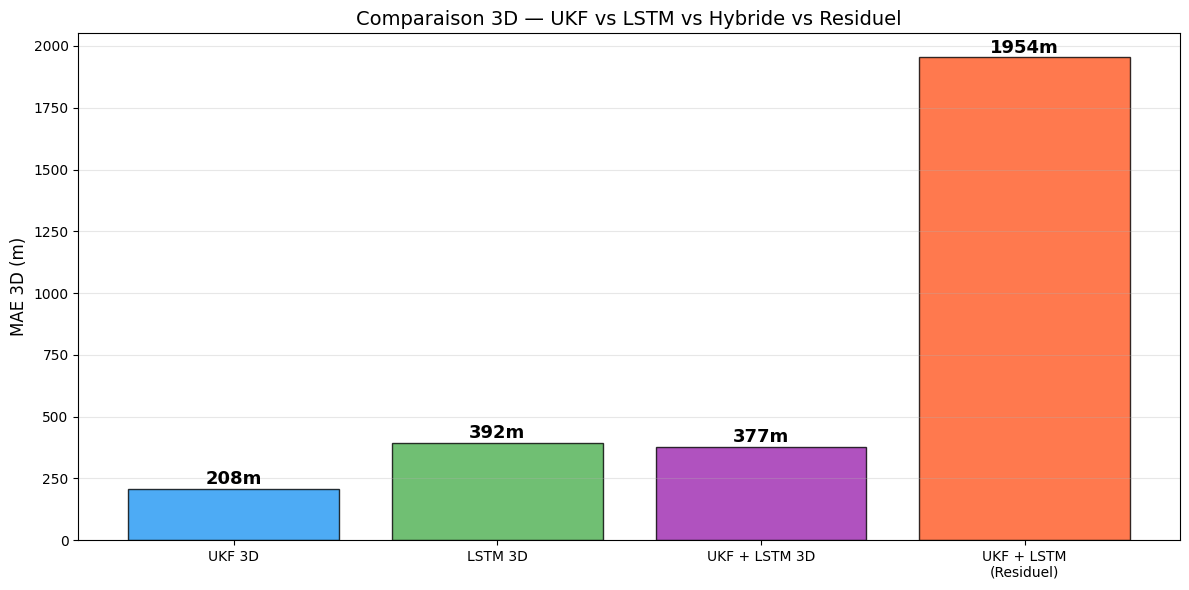

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

methodes = ['UKF 3D', 'LSTM 3D', 'UKF + LSTM 3D', 'UKF + LSTM\n(Residuel)']
maes = [np.mean(errs_ukf), np.mean(errs_mlp), np.mean(errs_hyb), np.mean(errs_res)]
couleurs = ['#2196F3', '#4CAF50', '#9C27B0', '#FF5722']

bars = ax.bar(methodes, maes, color=couleurs, alpha=0.8, edgecolor='black')
for bar, val in zip(bars, maes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val:.0f}m', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('MAE 3D (m)', fontsize=12)
ax.set_title('Comparaison 3D — UKF vs LSTM vs Hybride vs Residuel', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [ ]:
import plotly.graph_objects as go

# Nous utilisons la toute dernière trajectoire générée par la boucle (cellule précédente)
# xv, yv, zv : Vraie trajectoire
# xo, yo, zo : Mesures radar
# res_u['predictions'] : Trajectoire prédite par l'UKF
# fp : Impact prédit par le LSTM pur (en km, à multiplier par 1000)
# fph : Impact prédit par le LSTM hybride (en km, à multiplier par 1000)

fig = go.Figure()

# 1. Trajectoire Réelle
fig.add_trace(go.Scatter3d(
    x=xv, y=zv, z=yv, # On met 'y' (altitude) sur l'axe Z du graphique 3D pour la visualisation
    mode='lines',
    name='Trajectoire Réelle',
    line=dict(color='black', width=4)
))

# 2. Points Radar Bruités
fig.add_trace(go.Scatter3d(
    x=xo, y=zo, z=yo,
    mode='markers',
    name='Mesures Radar',
    marker=dict(color='red', size=3, opacity=0.5)
))

# 3. Trajectoire simulée par l'UKF
preds_ukf = res_u['predictions']
px = preds_ukf[:,0]; py = preds_ukf[:,1]; pz = preds_ukf[:,2]
fig.add_trace(go.Scatter3d(
    x=px, y=pz, z=py,
    mode='lines',
    name='Prédiction UKF 3D',
    line=dict(color='#2196F3', width=4, dash='dash')
))

# 4. Point d'impact prédit par LSTM pur
fig.add_trace(go.Scatter3d(
    x=[fp[0]*1000], y=[fp[1]*1000], z=[0],
    mode='markers',
    name='Impact LSTM pur',
    marker=dict(color='#4CAF50', size=8, symbol='x')
))

# 5. Point d'impact prédit par Hybride LSTM
fig.add_trace(go.Scatter3d(
    x=[fph[0]*1000], y=[fph[1]*1000], z=[0],
    mode='markers',
    name='Impact UKF+LSTM',
    marker=dict(color='#9C27B0', size=8, symbol='cross')
))

# Configuration visuelle
fig.update_layout(
    title='Visualisation 3D — Trajectoire Réelle vs Prédictions',
    scene=dict(
        xaxis_title='Distance X (m)',
        yaxis_title='Déviation Z (m)',
        zaxis_title='Altitude Y (m)',
        zaxis=dict(range=[0, max(yv)*1.1])
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()


In [ ]:
%%writefile ../src/ml/predictor3d.py
import numpy as np

class Radar3D:
    def __init__(self, sigma=30, frequence=10):
        self.sigma=sigma;self.frequence=frequence
    def observer(self, t_v, x_v, y_v, z_v, duree=8.0):
        m=t_v<=duree;to=t_v[m];xo=x_v[m];yo=y_v[m];zo=z_v[m]
        ind=np.arange(0,len(to),max(1,int(1.0/(self.frequence*0.1))))
        t=to[ind];xr=xo[ind];yr=yo[ind];zr=zo[ind]
        return {'t':t,'x':xr+np.random.normal(0,self.sigma,len(t)),
                'y':np.maximum(yr+np.random.normal(0,self.sigma,len(t)),0),
                'z':zr+np.random.normal(0,self.sigma,len(t)),'n':len(t)}

class UKF3D:
    def __init__(self, sigma_mesure=30.0):
        self.g=9.81;self.sm=sigma_mesure
        self.H=np.zeros((3,7));self.H[0,0]=1;self.H[1,1]=1;self.H[2,2]=1
        self.R=np.eye(3)*sigma_mesure**2
    def _f(self,s,dt):
        x,y,z,vx,vy,vz,k=s;v=np.sqrt(vx**2+vy**2+vz**2)
        if v>0 and k>0:ax=-k*v*vx;ay=-self.g-k*v*vy;az=-k*v*vz
        else:ax=0;ay=-self.g;az=0
        return np.array([x+vx*dt+.5*ax*dt**2,y+vy*dt+.5*ay*dt**2,z+vz*dt+.5*az*dt**2,vx+ax*dt,vy+ay*dt,vz+az*dt,k])
    def _jac(self,s,dt):
        x,y,z,vx,vy,vz,k=s;v=np.sqrt(vx**2+vy**2+vz**2);F=np.eye(7);F[0,3]=dt;F[1,4]=dt;F[2,5]=dt
        if v>1e-6 and k>0:
            dvx=vx/v;dvy=vy/v;dvz=vz/v
            F[0,3]+=.5*(-k*(v+vx*dvx))*dt**2;F[0,4]=.5*(-k*vx*dvy)*dt**2;F[0,5]=.5*(-k*vx*dvz)*dt**2;F[0,6]=.5*(-v*vx)*dt**2
            F[1,3]=.5*(-k*vy*dvx)*dt**2;F[1,4]+=.5*(-k*(v+vy*dvy))*dt**2;F[1,5]=.5*(-k*vy*dvz)*dt**2;F[1,6]=.5*(-v*vy)*dt**2
            F[2,3]=.5*(-k*vz*dvx)*dt**2;F[2,4]=.5*(-k*vz*dvy)*dt**2;F[2,5]+=.5*(-k*(v+vz*dvz))*dt**2;F[2,6]=.5*(-v*vz)*dt**2
            F[3,3]+=(-k*(v+vx*dvx))*dt;F[3,4]=(-k*vx*dvy)*dt;F[3,5]=(-k*vx*dvz)*dt;F[3,6]=(-v*vx)*dt
            F[4,3]=(-k*vy*dvx)*dt;F[4,4]+=(-k*(v+vy*dvy))*dt;F[4,5]=(-k*vy*dvz)*dt;F[4,6]=(-v*vy)*dt
            F[5,3]=(-k*vz*dvx)*dt;F[5,4]=(-k*vz*dvy)*dt;F[5,5]+=(-k*(v+vz*dvz))*dt;F[5,6]=(-v*vz)*dt
        return F
    def filtrer(self,t_obs,x_obs,y_obs,z_obs):
        if len(t_obs)<2:return np.array([[x_obs[0],y_obs[0],z_obs[0],0,0,0,0.0001]])
        dt=t_obs[1]-t_obs[0]
        self.x=np.array([x_obs[0],y_obs[0],z_obs[0],(x_obs[1]-x_obs[0])/dt,(y_obs[1]-y_obs[0])/dt,(z_obs[1]-z_obs[0])/dt,0.00008])
        self.P=np.diag([self.sm**2]*3+[(self.sm/dt)**2]*3+[0.0003**2])
        Q=np.diag([25]*3+[625]*3+[1e-10]);etats=[]
        for j in range(len(t_obs)):
            F=self._jac(self.x,dt);self.x=self._f(self.x,dt);self.P=F@self.P@F.T+Q
            self.x[6]=np.clip(self.x[6],1e-5,1e-3)
            z=np.array([x_obs[j],y_obs[j],z_obs[j]]);S=self.H@self.P@self.H.T+self.R
            K=self.P@self.H.T@np.linalg.inv(S);self.x=self.x+K@(z-self.H@self.x)
            self.x[6]=np.clip(self.x[6],1e-5,1e-3);self.P=(np.eye(7)-K@self.H)@self.P;etats.append(self.x.copy())
        return np.array(etats)

Overwriting ../src/ml/predictor3d.py
